In [55]:
import numpy as np
import pandas as pd
import seaborn as sns


In [56]:
df = pd.read_csv("C:\\sonu nayaka\\ML project\\HousePricePridiction\\Bengaluru_House_Data (1).csv")
df


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [57]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [58]:
print(df.columns)

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')


In [59]:
df = df.drop(['area_type', 'availability', 'society', 'balcony'], axis=1)
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [60]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [61]:
#handling missing values in location column
df['location'].value_counts() #count of houses in whitefield and sarajapur road is more than other locations
df['location']=df['location'].fillna("Sarjapur Road") 
df["location"].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1306, dtype: int64

In [62]:
df["size"].value_counts()
df['size']=df['size'].fillna("2 BHK")
df['size'].value_counts()

size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [63]:
df.isnull().sum()

location       0
size           0
total_sqft     0
bath          73
price          0
dtype: int64

In [64]:
mcd_bath=df['bath'].median()#[1,2,3,4,5,6,7,8,9,10 ]
mcd_bath
df['bath']=df['bath'].fillna(mcd_bath)

In [65]:
df["bath"]=df["bath"].astype(int)
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [66]:
df.drop_duplicates(inplace=True)

In [67]:
loc=df['location'].value_counts()
loc_less_than_10=loc[loc<10]
df['location']=df['location'].apply(lambda x:'other' if x in loc_less_than_10 else x)
df['location'].value_counts()


location
other                    2782
Whitefield                507
Sarjapur  Road            364
Electronic City           273
Thanisandra               224
                         ... 
Poorna Pragna Layout       10
Marsur                     10
1st Block Koramangala      10
Gunjur Palya               10
Dodsworth Layout           10
Name: count, Length: 248, dtype: int64

In [68]:
#handling size column
out=[int(i.split(' ')[0])for i in df['size']]#2bhk
df['bhk']=out
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,other,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [69]:
#handling total_sqft column
def clean_sqft(sqft):
    l=sqft.split('_')#[1200]
    if len(l)==2:
        return (float(l[0])+float(l[1]))/2
    try:#1200
        return float(l[0])
    except:#34,54j
        return None
    df['total_sqft']=df['total_sqft'].apply(clean_sqft)
    df['total_sqft']=df['total_sqft'].fillna(df['total_sqft'].mean())

In [70]:
#Check the datatype
print(df[['total_sqft', 'price']].dtypes)

total_sqft        str
price         float64
dtype: object


In [71]:
#Convert total_sqft to numeric
df['total_sqft'] = pd.to_numeric(df['total_sqft'], errors='coerce')


In [72]:
#check again the datatype
print(df[['total_sqft', 'price']].dtypes)

total_sqft    float64
price         float64
dtype: object


In [73]:
#create price_per_sqft column
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

#check result
print(df[['total_sqft','price','price_per_sqft']].head())

#dataset info
print(df.info())

   total_sqft   price  price_per_sqft
0      1056.0   39.07     3699.810606
1      2600.0  120.00     4615.384615
2      1440.0   62.00     4305.555556
3      1521.0   95.00     6245.890861
4      1200.0   51.00     4250.000000
<class 'pandas.DataFrame'>
Index: 12438 entries, 0 to 13318
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        12438 non-null  str    
 1   size            12438 non-null  str    
 2   total_sqft      12192 non-null  float64
 3   bath            12438 non-null  int64  
 4   price           12438 non-null  float64
 5   bhk             12438 non-null  int64  
 6   price_per_sqft  12192 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 978.0 KB
None


In [74]:
#handling outliers in total_sqft column
# total_sqrt/bhk>=300--> #to keep only those rows where total_sqrt/bhk is greater than or equal to 300
df=df[(df['total_sqft']/df['bhk']<300)]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,729.000000,729.000000,729.000000,729.000000,7.290000e+02
mean,971.802469,4.871056,130.064911,5.367627,3.534542e+04
std,454.435638,2.721475,80.987693,2.633125,4.532352e+05
min,1.000000,1.000000,8.000000,1.000000,2.045455e+03
25%,600.000000,3.000000,78.000000,4.000000,9.433962e+03
50%,940.000000,4.000000,110.000000,5.000000,1.250000e+04
75%,1200.000000,6.000000,162.000000,6.000000,1.600000e+04
max,8000.000000,40.000000,675.000000,43.000000,1.200000e+07


In [75]:
#handling outliers in bhk
df=df[df['bhk']<6]

In [76]:
# handling outliers in bath column
#bhk=2-->bath should be less than 4
df=df[df["bath"]<df["bhk"]+2]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
70,other,3 Bedroom,500.0,3,100.0,3,20000.000000
78,Kaval Byrasandra,2 BHK,460.0,1,22.0,2,4782.608696
119,Hennur Road,2 Bedroom,276.0,3,23.0,2,8333.333333
176,Kumaraswami Layout,5 Bedroom,600.0,3,85.0,5,14166.666667
258,other,5 Bedroom,1200.0,5,170.0,5,14166.666667
...,...,...,...,...,...,...,...
13112,Nagavara,3 Bedroom,440.0,3,35.0,3,7954.545455
13190,Yelahanka,5 Bedroom,1330.0,5,210.0,5,15789.473684
13216,other,1 BHK,250.0,2,40.0,1,16000.000000
13281,Margondanahalli,5 Bedroom,1375.0,5,125.0,5,9090.909091


<Axes: xlabel='price_per_sqft'>

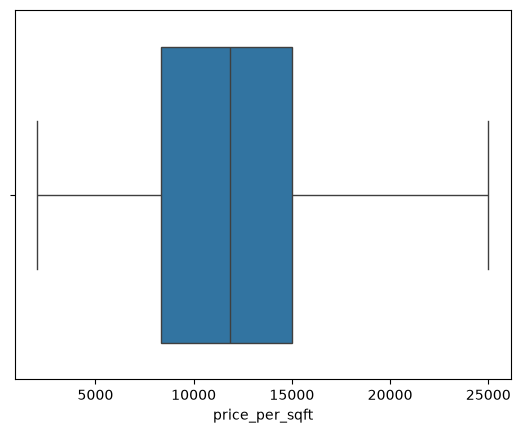

In [77]:
#handling outliers in price_per_sqft 
#sns.boxplot(x='price_per_sqft',data=df)
#IQR method--> #800-10000
q1 = df["price_per_sqft"].quantile(0.25)
q3 = df["price_per_sqft"].quantile(0.75)

IQR= q3 - q1 #2000-1200=800

lower_bound = q1 - 1.5 * IQR#800
upper_bound = q3 + 1.5 * IQR#2400

df=df[(df["price_per_sqft"]>=lower_bound) & (df["price_per_sqft"]<=upper_bound)]
sns.boxplot(x="price_per_sqft",data=df)

In [79]:
df.reset_index(inplace=True)
df=df.drop(["index","size","price_per_sqft"],axis=1)
df

,location,total_sqft,bath,price,bhk
0,other,500.0,3,100.0,3
1,Kaval Byrasandra,460.0,1,22.0,2
2,Hennur Road,276.0,3,23.0,2
3,Kumaraswami Layout,600.0,3,85.0,5
4,other,1200.0,5,170.0,5
...,...,...,...,...,...
408,Nagavara,440.0,3,35.0,3
409,Yelahanka,1330.0,5,210.0,5
410,other,250.0,2,40.0,1
411,Margondanahalli,1375.0,5,125.0,5


In [83]:
from sklearn.preprocessing import LabelEncoder,StandardScaler,Normalizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error

In [84]:
encoder = LabelEncoder()
df["encoder_loc"]=encoder.fit_transform(df["location"])
df.head()

,location,total_sqft,bath,price,bhk,encoder_loc
0,other,500.0,3,100.0,3,116
1,Kaval Byrasandra,460.0,1,22.0,2,61
2,Hennur Road,276.0,3,23.0,2,42
3,Kumaraswami Layout,600.0,3,85.0,5,68
4,other,1200.0,5,170.0,5,116


In [85]:
#divide into input and output
x=df.drop(["location","price"],axis=1)
y=df.price

In [86]:
#split the data into training and testing data
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)


In [89]:
#model training
# Convert categorical columns into numeric columns
model = RandomForestRegressor(random_state=42)
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20]
}
grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5
)
grid.fit(xtrain, ytrain)
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'max_depth': 10, 'n_estimators': 200}
Best score: 0.42011695844915736


In [90]:
ypred = grid.predict(xtest)

In [91]:
print("Training Eff: ", grid.score(xtrain,ytrain))
print("Testing Eff:",grid.score(xtest,ypred))

Training Eff:  0.8553362008055537
Testing Eff: 1.0


In [92]:
print("R2: ",r2_score(ytest,ypred))
print("MAE:",mean_absolute_error(ytest,ypred))

R2:  0.39989651294384865
MAE: 30.65778854080576


In [93]:
#save cleaned dataset
df.to_csv("cleaned_df.csv")

In [ ]:
#save the model in pickle file
import joblib
joblib.dump(grid, "rf_model.joblib")

['rf_model.joblib']